In [1]:
%load_ext autoreload
%autoreload 2

import pickle
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax.random as jrand

from gvabm.abm_event import build_conditional_sampler, sample_event_optstate
from gvabm.abm_ll import city_ll, eval_ds
from gvabm.stat_utils import logrange
from gvabm.param_distr import ParamDistr, param_config, mixed_choice_param_config, CityParams, EventOutcome, GeneralParams, MixedGeneralParams
from gvabm.city_data import subsampled_city_data, subsample_weights
has_event = np.array([len(c['events']) > 0 for c in subsampled_city_data])

sample_func = build_conditional_sampler(sample_event_optstate)
param_distr = ParamDistr(mixed_choice_param_config)
rng_key = jrand.PRNGKey(1)
param_l = [param_distr.transform_sample(param_distr.sample_range(r)) for r in jrand.split(rng_key, 10)]

In [89]:
subsampled_city_data_updated = []
for city in subsampled_city_data:
    thresholded_params = city['params']._replace(arm_density=float(city['params'].arm_density > 0.1))
    subsampled_city_data_updated.append({'events': city['events'], 'params': thresholded_params})

In [42]:
subsampled_city_data_updated

[{'events': [],
  'params': CityParams(population=157, population_density=152.1, arm_count=80.0, arm_density=0.0)},
 {'events': [],
  'params': CityParams(population=199965, population_density=1546.2, arm_count=125.0, arm_density=1.0)},
 {'events': [],
  'params': CityParams(population=4277, population_density=1250.2, arm_count=67.0, arm_density=0.0)},
 {'events': [],
  'params': CityParams(population=1880, population_density=96.0, arm_count=26.0, arm_density=0.0)},
 {'events': [],
  'params': CityParams(population=2169, population_density=403.4, arm_count=96.00000000000001, arm_density=0.0)},
 {'events': [],
  'params': CityParams(population=1915031, population_density=1145.0, arm_count=111.00000000000001, arm_density=1.0)},
 {'events': [EventOutcome(date='3/27/23', fatalities=6, injured=6, total_victims=12),
   EventOutcome(date='4/22/18', fatalities=4, injured=4, total_victims=8)],
  'params': CityParams(population=1178679.0, population_density=555.6, arm_count=84.00000000000001, ar

In [38]:
timespan = 50
eval_l = []
data_l = []
param_l = []
# general_params = MixedGeneralParams(propensity=1e-7, walk_radius=29, arm_bias=0.05, arm_weight=0.6, atrisk_gathering_rate=1e-3, mix_perc=0.05)
for r in np.linspace(-2.5, 2, 20):
    param = np.power(10, r)
    general_params = MixedGeneralParams(propensity=1.02e-07, walk_radius=15, arm_bias=0.07, arm_weight=param, atrisk_gathering_rate=1e-4, mix_perc=0.3)
    ll_data = eval_ds(subsampled_city_data, general_params, timespan, rng_key, num_samples=10000, sample_func=sample_func)
    ll_total = (ll_data * subsample_weights.reshape(-1,1)).sum(axis=0)[0]
    ll_totals = ll_data[:, 0] * subsample_weights
    eval_l.append(ll_total)
    param_l.append(param)
    data_l.append(ll_data)
    print(ll_totals[has_event].sum(), ll_totals[~has_event].sum(), ll_totals.sum())

-767.6461457839312 -67.78102515480595 -835.4271709387372


KeyboardInterrupt: 

In [36]:
#get index of str containing 'BROOKLYN' in subsampled_city_data_names
brooklyn_index = [i for i, s in enumerate(subsampled_city_data_names) if 'FLORIDA' in s][2]
print(brooklyn_index, subsampled_city_data_names[brooklyn_index])
print(subsampled_city_data[brooklyn_index])

# print([subsampled_city_data_names[i] for i in np.argsort(pop_l)[-5:]])
for i in np.argsort(pop_l)[-5:]:
    print(subsampled_city_data_names[i])
    print(subsampled_city_data[i])


67 ORLANDO, FLORIDA
{'events': [EventOutcome(date='6/5/2017', fatalities=5, injured=0, total_victims=5), EventOutcome(date='6/12/2016', fatalities=49, injured=53, total_victims=102)], 'params': CityParams(population=1913597.0, population_density=1082.0, arm_count=144.0, arm_density=0.07337579617834394)}
DALLAS, TEXAS
{'events': [EventOutcome(date='7/7/2016', fatalities=5, injured=11, total_victims=16), EventOutcome(date='6/29/1984', fatalities=6, injured=1, total_victims=7)], 'params': CityParams(population=5843632.0, population_density=1477.2, arm_count=306.0, arm_density=0.1559235668789809)}
HOUSTON, TEXAS
{'events': [], 'params': CityParams(population=6046392, population_density=1386.5, arm_count=244.0, arm_density=0.1243312101910828)}
MIAMI, FLORIDA
{'events': [EventOutcome(date='8/20/1982', fatalities=8, injured=3, total_victims=11)], 'params': CityParams(population=6113982.0, population_density=4791.1, arm_count=79.0, arm_density=0.040254777070063696)}
CHICAGO, ILLINOIS
{'events'

In [84]:
arm_density_l = np.array([c['params'].arm_density for c in subsampled_city_data])
arm_count_l = np.array([c['params'].arm_count for c in subsampled_city_data])

pop_l = np.array([c['params'].population for c in subsampled_city_data])
pop_density_l = np.array([c['params'].population_density for c in subsampled_city_data])
y = has_event

#train a logistic regression model to predict has_event from arm_density, pop, pop_density
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
X = np.vstack([arm_density_l / pop_density_l, pop_density_l, pop_l]).T
model = make_pipeline(StandardScaler(), LogisticRegression())
model.fit(X, y, logisticregression__sample_weight=subsample_weights)
print(model.named_steps['logisticregression'].coef_, model.named_steps['logisticregression'].intercept_)
#print model accuracy
y_pred = model.predict(X)
accuracy = ((y_pred == y) * subsample_weights).sum() / subsample_weights.sum()
# loglikelihood = model.predict_log_proba(X) * subsample_weights.reshape(-1,1) 
# print("Model log-likelihood:", loglikelihood)
print("Model accuracy:", accuracy)

# #Run bagging to get confidence intervals on the logistic regression coefficients
# n_bootstraps = 1000
# coef_l = []
# intercept_l = []
# n_samples = len(y)
# for i in range(n_bootstraps):
#     indices = np.random.choice(n_samples, n_samples, replace=True)
#     X_bootstrap = X[indices]
#     y_bootstrap = y[indices]
#     sample_weights_bootstrap = subsample_weights[indices]
#     model_bootstrap = make_pipeline(StandardScaler(), LogisticRegression())
#     model_bootstrap.fit(X_bootstrap, y_bootstrap, logisticregression__sample_weight=sample_weights_bootstrap)
#     coef_l.append(model_bootstrap.named_steps['logisticregression'].coef_[0])
#     intercept_l.append(model_bootstrap.named_steps['logisticregression'].intercept_[0])
# coef_l = np.array(coef_l)
# intercept_l = np.array(intercept_l)
# coef_ci = np.percentile(coef_l, [2.5, 97.5], axis=0)
# intercept_ci = np.percentile(intercept_l, [2.5, 97.5], axis=0)
# print("Coefficient confidence intervals:", coef_ci)
# print("Intercept confidence interval:", intercept_ci)

[[-0.07037921  0.33450857  1.01264607]] [-5.3035302]
Model accuracy: 0.996136570318841


In [136]:
# pop_density_l.mean(), pop_density_l.std()
# (pop_density_l > 200).mean()
(has_event * (pop_density_l <= 150)).sum() / has_event.sum()

np.float64(0.03305785123966942)

In [139]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Example data: each row is a county or zip code
df = pd.DataFrame({
    'mass_shootings': [len(c['events']) for c in subsampled_city_data],
    'arm_density': [c['params'].arm_density / c['params'].population_density for c in subsampled_city_data],
    'population_density': [c['params'].population_density for c in subsampled_city_data],
    'population': [c['params'].population for c in subsampled_city_data]
})

# Add log(population) as the offset
df['log_population'] = np.log(df['population'])
df['population_density_threshold'] = (df['population_density'] > 100).astype(float)
df['arm_density_threshold'] = (df['arm_density'] > 0.1).astype(float)

# Define model
X = sm.add_constant(df['arm_density'])
y = df['mass_shootings']

# Fit Poisson regression with log(population) as offset
poisson_model = sm.GLM(y, X, 
                       family=sm.families.Poisson(), freq_weights=subsample_weights,
                       offset=df['log_population'])

results = poisson_model.fit()
print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         mass_shootings   No. Observations:                  443
Model:                            GLM   Df Residuals:                 32667.20
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -554.32
Date:                Thu, 23 Oct 2025   Deviance:                       857.67
Time:                        17:54:41   Pearson chi2:                 2.83e+04
No. Iterations:                    11   Pseudo R-squ. (CS):          0.0002962
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -14.9302      0.086   -173.238      

Text(0.5, 1.0, 'City Log-Likelihood by Arm Density and Population')

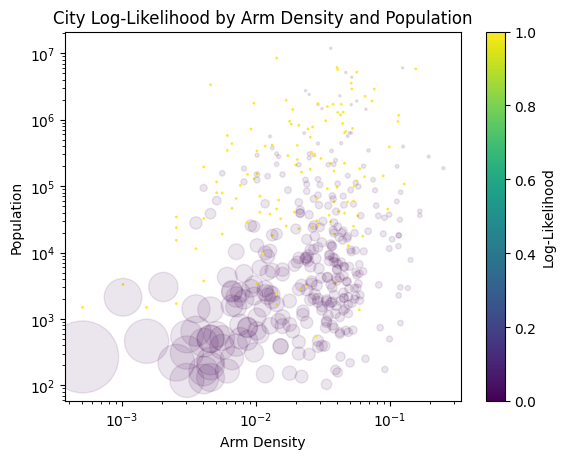

In [114]:
normed_arm_density_l = arm_density_l / pop_density_l

plt.scatter(arm_density_l, pop_l, c=has_event, s=subsample_weights, alpha=0.1+0.8*has_event, cmap='viridis')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Arm Density')
plt.ylabel('Population')
plt.colorbar(label='Log-Likelihood')
plt.title('City Log-Likelihood by Arm Density and Population')


In [14]:
from gvabm.city_data import subsampled_city_data_names
high_pop_ind = np.array([c['params'].population > 1_000_000 for c in subsampled_city_data]).nonzero()[0]
high_ad_ind = np.array([c['params'].arm_density > 0.1 for c in subsampled_city_data]).nonzero()[0]
# print([subsampled_city_data_names[i] for i in high_pop_ind])
# print([subsampled_city_data[i] for i in high_pop_ind])
for i in high_ad_ind:
    print(subsampled_city_data_names[i])
    print(subsampled_city_data[i])

# print(subsampled_city_data_names)

HOUSTON, TEXAS
{'events': [], 'params': CityParams(population=6046392, population_density=1386.5, arm_count=244.0, arm_density=0.1243312101910828)}
BLUFFDALE, UTAH
{'events': [], 'params': CityParams(population=18168, population_density=631.3, arm_count=228.00000000000003, arm_density=0.11617834394904458)}
RIO_VERDE, ARIZONA
{'events': [], 'params': CityParams(population=2271, population_density=202.5, arm_count=228.00000000000003, arm_density=0.11617834394904458)}
WHITE_SETTLEMENT, TEXAS
{'events': [], 'params': CityParams(population=18119, population_density=1388.9, arm_count=229.0, arm_density=0.11668789808917197)}
FARMERS_BRANCH, TEXAS
{'events': [], 'params': CityParams(population=36254, population_density=1178.2, arm_count=328.0, arm_density=0.16713375796178345)}
HACKBERRY, TEXAS
{'events': [], 'params': CityParams(population=2927, population_density=1664.5, arm_count=267.0, arm_density=0.13605095541401274)}
SALT_LAKE_CITY, UTAH
{'events': [EventOutcome(date='2/12/2007', fataliti

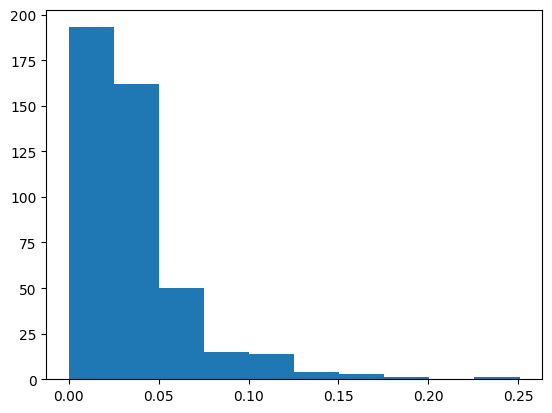

In [5]:
arm_density_val = np.array([c['params'].arm_density for c in subsampled_city_data])
plt.hist(arm_density_val, bins=10)
plt.show()

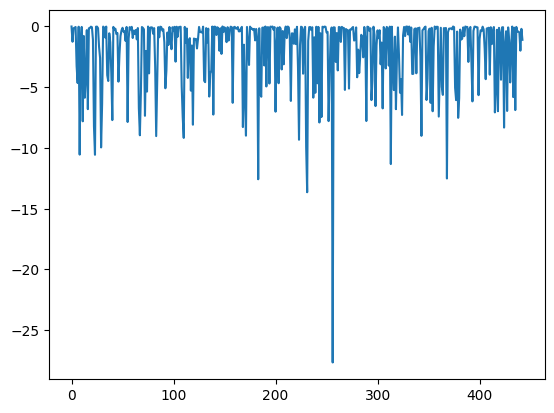

In [6]:
plt.plot(ll_totals)

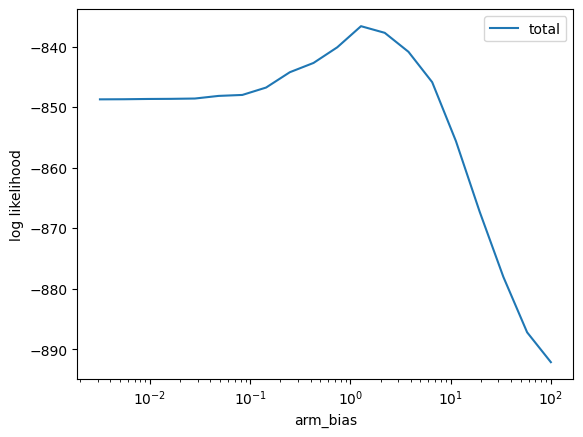

In [8]:
ll_total_data = np.array([(data[:, 0] * subsample_weights) for data in data_l])
has_event = np.array([len(c['events']) > 0 for c in subsampled_city_data])
high_event_mask = np.array([len(c['events']) > 0 and max(e.fatalities for e in c['events']) > 25 for c in subsampled_city_data])
low_event_mask = np.array([len(c['events']) > 0 and max(e.fatalities for e in c['events']) < 5 for c in subsampled_city_data])
high_density_mask = np.array([c['params'].population_density > 3000 for c in subsampled_city_data])
low_density_mask  = np.array([c['params'].population_density < 1000 for c in subsampled_city_data])
mask = low_event_mask

plt.plot(param_l, ll_total_data[:, :].sum(axis=1), label='total')
# plt.plot(param_l, ll_total_data[:, has_event].sum(axis=1), label='has event')
# plt.plot(param_l, ll_total_data[:, ~has_event].sum(axis=1), label='no event')
# plt.plot(param_l, ll_total_data[:, high_density_mask].sum(axis=1), label='high density')
# plt.plot(param_l, ll_total_data[:, low_density_mask].sum(axis=1), label='low density')
plt.xlabel('arm_bias')
plt.ylabel('log likelihood')
plt.xscale('log')
plt.legend()   
plt.show()

In [2]:
timespan = 50
eval_l = []
data_l = []
bias_l = []
# general_params = MixedGeneralParams(propensity=1e-7, walk_radius=29, arm_bias=0.05, arm_weight=0.6, atrisk_gathering_rate=1e-3, mix_perc=0.05)
for r in np.linspace(-2, 1, 16):
    arm_bias = np.power(10, r)
    general_params = MixedGeneralParams(propensity=6.02e-08, walk_radius=15, arm_bias=arm_bias, arm_weight=0.01, atrisk_gathering_rate=8.6441395e-03, mix_perc=0.5)
    ll_data = eval_ds(subsampled_city_data, general_params, timespan, rng_key, num_samples=10000, sample_func=sample_func)
    ll_total = (ll_data * subsample_weights.reshape(-1,1)).sum(axis=0)[0]
    ll_totals = ll_data[:, 0] * subsample_weights
    eval_l.append(ll_total)
    bias_l.append(arm_bias)
    data_l.append(ll_data)
    print(ll_totals[has_event].sum(), ll_totals[~has_event].sum(), ll_totals.sum())

-884.9310334669567 -34.419043002078254 -919.3500764690348
-833.5388963750646 -52.14076017316602 -885.6796565482306
-787.257008994966 -77.46777850853913 -864.7247875035051
-748.0078951955707 -111.99575224071553 -860.0036474362862
-717.2685569547806 -156.1044456976723 -873.3730026524529
-698.2763872437531 -206.74308909572534 -905.0194763394784
-690.099611912619 -259.53728736676817 -949.6368992793872


KeyboardInterrupt: 

In [ ]:
# eval_l = eval_l[:12]; bias_l = bias_l[:12]; data_l = data_l[:12]

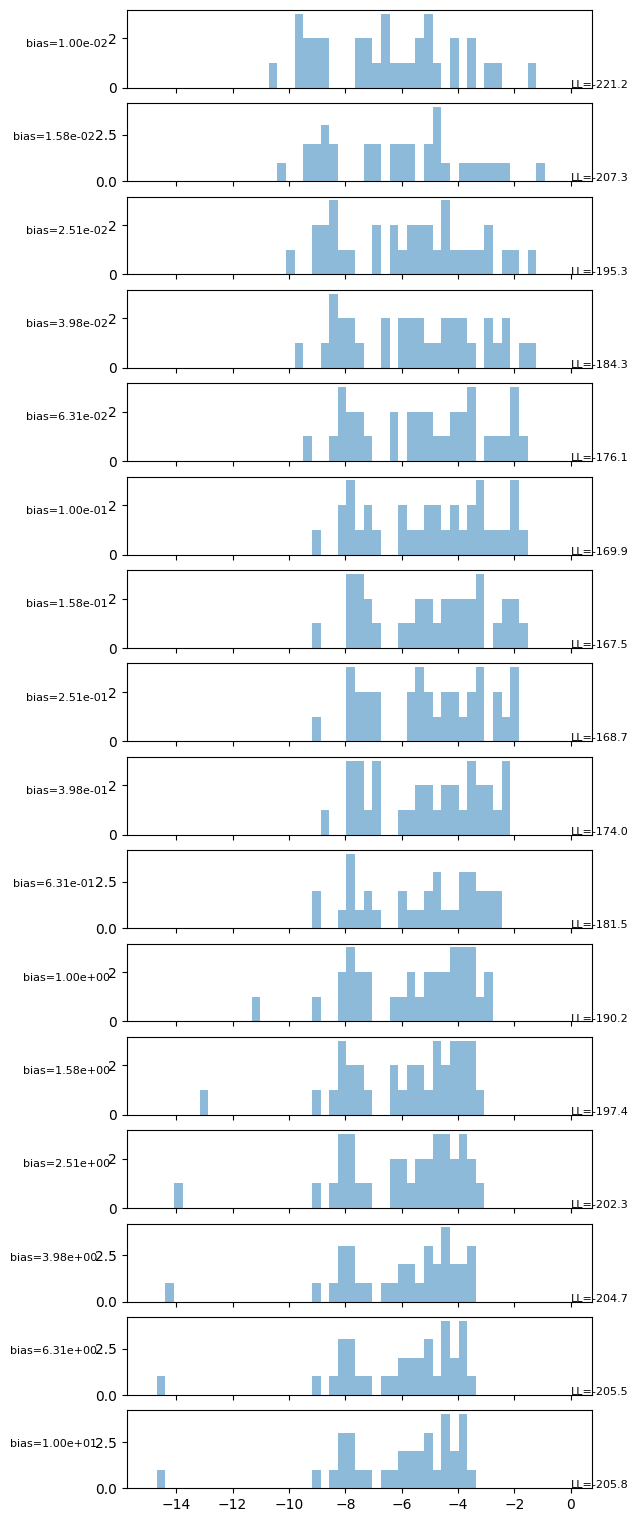

In [7]:
fig, ax = plt.subplots(len(bias_l), 1, figsize=(6, 1.2*len(bias_l)), sharex=True)
has_event = np.array([len(c['events']) > 0 for c in subsampled_city_data])
high_event_mask = np.array([len(c['events']) > 0 and max(e.fatalities for e in c['events']) > 25 for c in subsampled_city_data])
low_event_mask = np.array([len(c['events']) > 0 and max(e.fatalities for e in c['events']) < 5 for c in subsampled_city_data])
mask = low_event_mask

ll_total_data = np.array([(data[:, 0] * subsample_weights) for data in data_l])
for i in range(len(bias_l)):
    has_event_total = ll_total_data[i][mask].sum()
    ax[i].hist(data_l[i][mask, 0], bins=np.linspace(-15, 0), alpha=0.5, label='with event')
    # ax[i].hist(data_l[i][~has_event, 0]*subsample_weights[~has_event], bins=np.linspace(-10, 0), alpha=0.5, label='no event')
    ax[i].set_ylabel(f'bias={bias_l[i]:.2e}', fontsize=8, rotation=0, labelpad=30)
    ax[i].text(0, 0, f'LL={has_event_total:.1f}', fontsize=8)
plt.show()

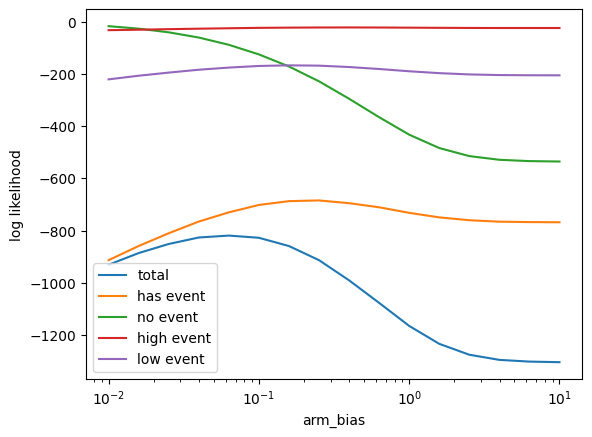

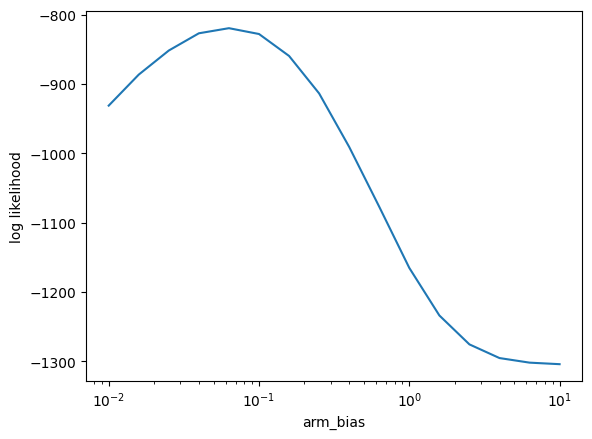

In [9]:
plt.plot(bias_l, eval_l)
plt.xlabel('arm_bias')
plt.ylabel('log likelihood')
plt.xscale('log')

In [6]:
eval_params = param_distr.inverse_transform_sample(np.array(general_params))

In [7]:
eval_params

Array([0.4       , 0.26666668, 0.52842426, 0.6825931 , 0.8333334 ,
       0.0909091 ], dtype=float32)

In [ ]:
# ll_data[~has_event, 0]*subsample_weights[~has_event]

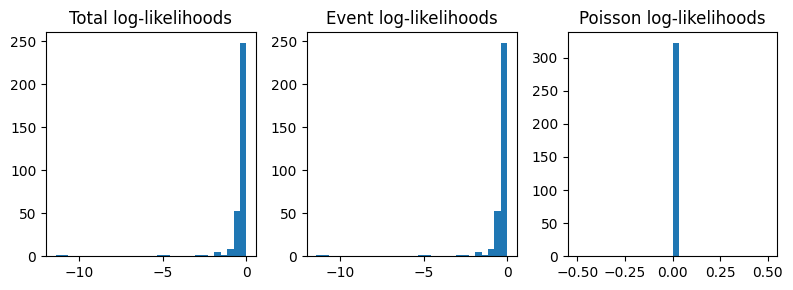

In [32]:

fig, axes = plt.subplots(1,3,figsize=(8,3))
mask = ~has_event
axes[0].hist(ll_data[mask, 0] * subsample_weights[mask], bins=30)
axes[0].set_title('Total log-likelihoods')
axes[1].hist(ll_data[mask, 1] * subsample_weights[mask], bins=30)
axes[1].set_title('Event log-likelihoods')
axes[2].hist(ll_data[mask, 2] * subsample_weights[mask], bins=30)
axes[2].set_title('Poisson log-likelihoods')
plt.tight_layout()
plt.show()

In [21]:
ll_total

np.float64(-2854.2177850110947)

In [20]:
(np.isnan(ll_data[:,0])).sum()

np.int64(0)

In [11]:
print(ll_data[~np.isnan(ll_data[:,0])])

[[-1.48981899e-16 -1.48981899e-16  0.00000000e+00]
 [-7.55533669e-17 -7.55533669e-17  0.00000000e+00]
 [-1.48180738e-16 -1.48180738e-16  0.00000000e+00]
 [-2.34079573e-17 -2.34079573e-17  0.00000000e+00]
 [-7.91063525e-17 -7.91063525e-17  0.00000000e+00]
 [-5.87570086e-14 -5.87570086e-14  0.00000000e+00]
 [-2.21094551e+01 -3.51652336e+01  1.30557774e+01]
 [-1.82520943e+01 -3.13078728e+01  1.30557774e+01]
 [-2.60204524e-16 -2.60204524e-16  0.00000000e+00]
 [-6.31143995e-16 -6.31143995e-16  0.00000000e+00]
 [-1.98067741e+01 -3.28625526e+01  1.30557774e+01]
 [-3.01461038e-15 -3.01461038e-15  0.00000000e+00]
 [-6.08502381e-16 -6.08502381e-16  0.00000000e+00]
 [-5.51062298e-17 -5.51062298e-17  0.00000000e+00]
 [-2.90997137e-16 -2.90997137e-16  0.00000000e+00]
 [-7.63545277e-17 -7.63545277e-17  0.00000000e+00]
 [-1.46613237e-16 -1.46613237e-16  0.00000000e+00]
 [-1.26284534e-15 -1.26284534e-15  0.00000000e+00]
 [-1.46334577e-16 -1.46334577e-16  0.00000000e+00]
 [-1.89492983e-17 -1.89492983e-

In [ ]:
general_params

In [4]:
from gvabm.abm_vbmc import get_param_density_func_noisy
model_name = 'max_select'
sample_func = {'max_select': conditional_sample, 'sample_select': conditional_sample_noselection, 'mixed_choice': conditional_sample_mixed}[model_name]
param_config = {'max_select': param_config, 'sample_select': param_config, 'mixed_choice': mixed_choice_param_config}[model_name]
param_distr = ParamDistr(param_config)
prior = param_distr.get_uniform_prior()

density_func = get_param_density_func_noisy(sample_func, param_distr, jrand.PRNGKey(0), num_samples=10000)
P = density_func

from pyvbmc import VBMC
D = param_distr.param_count
LB = np.full((1, D), -np.inf); UB = np.full((1, D), np.inf)
PLB = param_distr.range_lower.reshape((1, -1)); PUB = param_distr.range_upper.reshape((1, -1))
x0 = np.array([-7.49712599, 38.49844685,  0.70090904, -1.13903331, -4.42167238]) #hardcode first sample for convenience
P(x0)

Evaluating params: [-7.497126  38.498447   0.700909  -1.1390333 -4.4216723]
prior 9.5367386e-07
Log posterior: -897.847900390625


(Array(-897.8479, dtype=float32), 0.8)

In [ ]:
import matplotlib.pyplot as plt
import pickle
# with open('data/ll_eval_153.pkl', 'rb') as f: #Eval over all axis ll_eval_b4c26.pkl
# with open('data/ll_eval_dc111.pkl', 'rb') as f: #2D grid search over propensity, atrisk
with open('data/ll_eval_17a46.pkl', 'rb') as f: #2D grid search over propensity, atrisk
    ll_eval = pickle.load(f)

In [2]:
import numpy as np
import pickle
from stat_utils import CityParams, EventOutcome, GeneralParams
from city_data import subsampled_city_data, subsample_weights
n_event = np.array([len(c['events']) for c in subsampled_city_data])

In [3]:
total_ll = {params: (subsample_weights.reshape((-1, 1))*city_eval).sum(axis=0)[0] for params, city_eval in ll_eval.items()}
param_groups = [p for p in ll_eval]
ll_list = [(subsample_weights.reshape((-1, 1))*ll_eval[p]).sum(axis=0) for p in param_groups]
import pandas as pd
result_df = pd.DataFrame(param_groups)
eval_df = pd.DataFrame(ll_list)
result_df = pd.concat([result_df, eval_df], axis=1)
result_df['city_eval'] = [ll_eval[p] for p in param_groups]

np.float64(-inf)

In [5]:
lookup_df = result_df.set_index(['propensity',  'walk_radius',  'arm_bias',  'arm_weight',  'atrisk_gathering_rate'])
params = ['propensity',  'walk_radius',  'arm_bias',  'arm_weight',  'atrisk_gathering_rate']
param_val = [np.sort(result_df[p].unique()) for p in params]
param_grid = np.meshgrid(*param_val, indexing='ij')

In [6]:
from itertools import product
eval_grid = np.zeros(param_grid[0].shape).flatten()
for i, p in enumerate(product(*param_val)):
    eval_grid[i] = lookup_df.loc[p][0]
eval_grid = eval_grid.reshape(param_grid[0].shape)

In [14]:
param_stack = np.stack([p for p in param_grid], axis=-1)
print(param_stack.shape, eval_grid.shape)

(10, 2, 2, 2, 10, 5) (10, 2, 2, 2, 10)


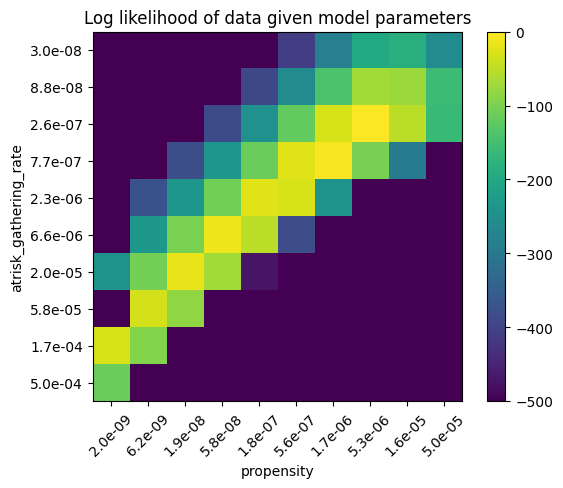

In [44]:
eval_slice = eval_grid.max(axis=1).max(axis=1).max(axis=1)  # Slice over walk_radius, arm_bias, arm_weight
eval_slice = eval_grid[:, 1, 1, 1, :]  # Slice over walk_radius, arm_bias, arm_weight

Z = eval_slice
mat = Z - Z.max()
cutoff = -500
mat[np.isneginf(mat)] = cutoff
mat = mat*(mat > cutoff) + cutoff*(mat <= cutoff)

plt.imshow(mat)
plt.xticks(range(len(param_val[0])), ['%.1e' % p for p in param_val[0]], rotation=45)
plt.yticks(range(len(param_val[4])), ['%.1e' % p for p in param_val[4]])
plt.xlabel('propensity')
plt.ylabel('atrisk_gathering_rate')
plt.colorbar()
plt.title('Log likelihood of data given model parameters')
plt.show()

In [38]:
X = param_stack.reshape(-1, param_stack.shape[-1])
y = eval_grid.flatten()

In [42]:
#set negative inf to minimum non-inf value
min_noninf = y[np.isfinite(y)].min()
y[~np.isfinite(y)] = min_noninf - 10.0

In [40]:
import numpy as np
from itertools import combinations_with_replacement
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def quadratic_features(X):
    """
    Build quadratic feature matrix for X.
    Includes constant, linear, and quadratic terms.
    """
    n, d = X.shape
    feats = [np.ones((n, 1))]        # constant
    feats.append(X)                  # linear terms

    # quadratic terms (i <= j to avoid duplicates)
    quad_terms = []
    for i, j in combinations_with_replacement(range(d), 2):
        quad_terms.append((X[:, i] * X[:, j])[:, None])
    feats.append(np.hstack(quad_terms))

    return np.hstack(feats)

import numpy as np
from itertools import combinations_with_replacement
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def quadratic_features(X):
    """
    Build quadratic feature matrix for X.
    Includes constant, linear, and quadratic terms.
    """
    n, d = X.shape
    feats = [np.ones((n, 1))]        # constant
    feats.append(X)                  # linear terms

    # quadratic terms (i <= j to avoid duplicates)
    quad_terms = []
    for i, j in combinations_with_replacement(range(d), 2):
        quad_terms.append((X[:, i] * X[:, j])[:, None])
    feats.append(np.hstack(quad_terms))

    return np.hstack(feats)


def fit_quadratic(X, y):
    """
    Fit quadratic model y ≈ c + b^T x + 0.5 x^T A x

    Returns
    -------
    c : float
        Constant term
    b : array, shape (d,)
        Linear coefficients
    A : array, shape (d, d)
        Symmetric quadratic matrix
    errors : dict
        MSE, RMSE, R^2
    """
    n, d = X.shape
    Phi = quadratic_features(X)

    # Fit regression
    reg = LinearRegression(fit_intercept=False)
    reg.fit(Phi, y)
    y_pred = reg.predict(Phi)

    # Extract parameters
    coef = reg.coef_

    c = coef[0]
    b = coef[1:1+d]

    A = np.zeros((d, d))
    idx = 1 + d
    for i, j in combinations_with_replacement(range(d), 2):
        A[i, j] = coef[idx]
        A[j, i] = coef[idx]  # symmetric
        idx += 1

    # Error metrics
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)
    errors = {"MSE": mse, "RMSE": rmse, "R2": r2}

    return c, b, A, errors

In [41]:
c, b, A, errors = fit_quadratic(X, y)

print("Fitted constant:", c)
print("Fitted linear b:", b)
print("Fitted quadratic A:\n", A)
print("Errors:", errors)

Fitted constant: -316509.5489567125
Fitted linear b: [ 5.56263805e+08  8.81411675e+03 -6.52192301e+04  5.24747690e+04
  2.02400948e+09]
Fitted quadratic A:
 [[ 2.72662015e+04 -7.53014024e+07  6.64226484e+08 -4.69511929e+08
  -1.69336405e+13]
 [-7.53014024e+07 -5.70997005e+01 -1.18151027e+03 -4.59355564e+03
  -1.69699589e+07]
 [ 6.64226484e+08 -1.18151027e+03  9.70772187e+04  1.97243776e+05
  -7.42692153e+07]
 [-4.69511929e+08 -4.59355564e+03  1.97243776e+05  5.63902262e+03
  -1.15319216e+08]
 [-1.69336405e+13 -1.69699589e+07 -7.42692153e+07 -1.15319216e+08
  -2.48682246e+12]]
Errors: {'MSE': 45712893656.41354, 'RMSE': np.float64(213805.7381278939), 'R2': 0.17633533457764206}


In [21]:
mu, Sigma

(array([4.47888703e-08, 2.04601255e+01, 5.67705771e-01, 4.23865529e-02,
        1.30618266e-04]),
 array([[ 4.39374544e-16, -2.68046248e-07,  8.92041348e-10,
         -8.15552136e-11,  9.98099548e-13],
        [-2.68046248e-07,  2.04389539e+02, -6.78224282e-01,
          6.33371087e-02, -7.65104790e-04],
        [ 8.92041348e-10, -6.78224282e-01,  1.22186506e-01,
         -9.02978696e-04,  2.54097679e-06],
        [-8.15552136e-11,  6.33371087e-02, -9.02978696e-04,
          1.86590095e-03, -2.37609768e-07],
        [ 9.98099548e-13, -7.65104790e-04,  2.54097679e-06,
         -2.37609768e-07,  2.86652213e-09]]))

In [ ]:
# param_grid_tuples = [tuple(param_grids[i].flatten()) for i in range(len(param_grids))]

In [42]:
# result_df[0]
# plt.hist(result_df[0], bins=np.linspace(-4000, -400, 100))
# plt.show()

In [69]:
grid_height = {(p.propensity, p.atrisk_gathering_rate): ll for p, ll in total_ll.items()}
propensity_range = np.unique(result_df['propensity']); atrisk_range = np.unique(result_df['atrisk_gathering_rate'])
propensity_range.sort(); atrisk_range.sort()
Z = np.array([[grid_height.get((propensity_range[x], atrisk_range[y]), -np.inf) for x in range(len(propensity_range))] for y in range(len(atrisk_range))])


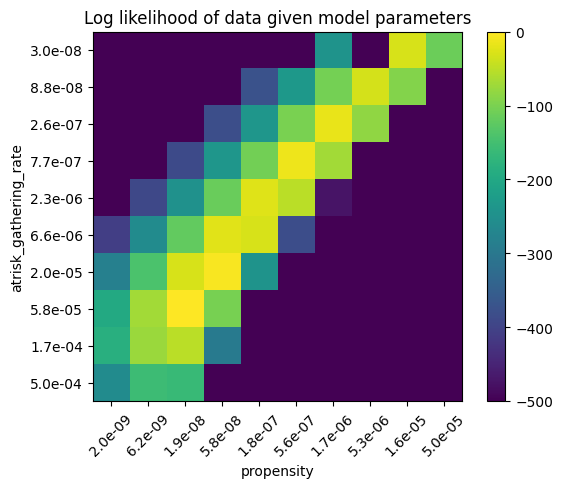

In [38]:
mat = Z - Z.max()
cutoff = -500
mat[np.isneginf(mat)] = cutoff
mat = mat*(mat > cutoff) + cutoff*(mat <= cutoff)

plt.imshow(mat)
plt.xticks(range(len(propensity_range)), ['%.1e' % p for p in propensity_range], rotation=45)
plt.yticks(range(len(atrisk_range)), ['%.1e' % p for p in atrisk_range])
plt.xlabel('propensity')
plt.ylabel('atrisk_gathering_rate')
plt.colorbar()
plt.title('Log likelihood of data given model parameters')
plt.show()

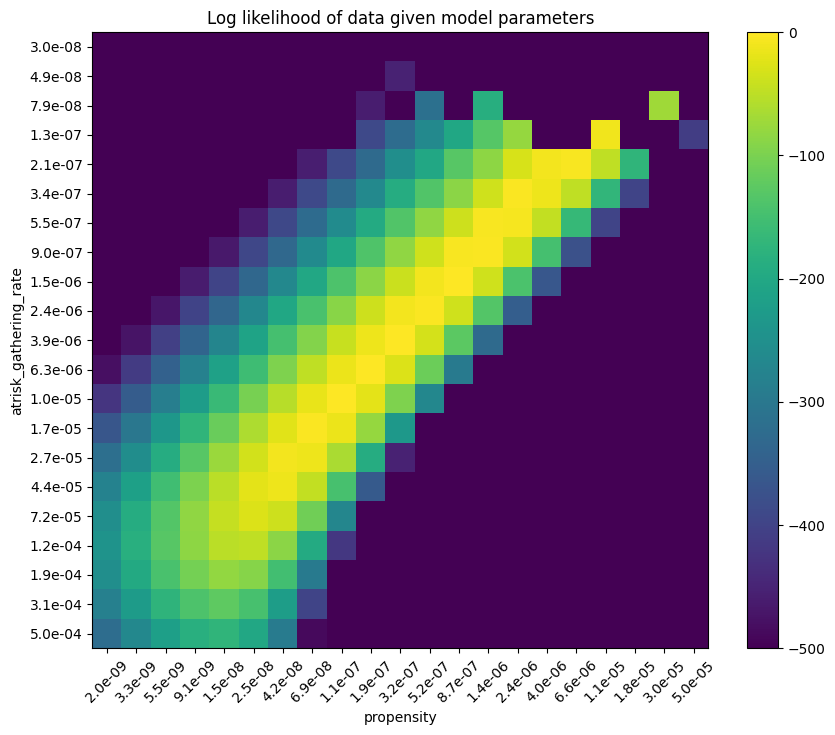

/tmp/ipykernel_1830307/1142763385.py:66: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


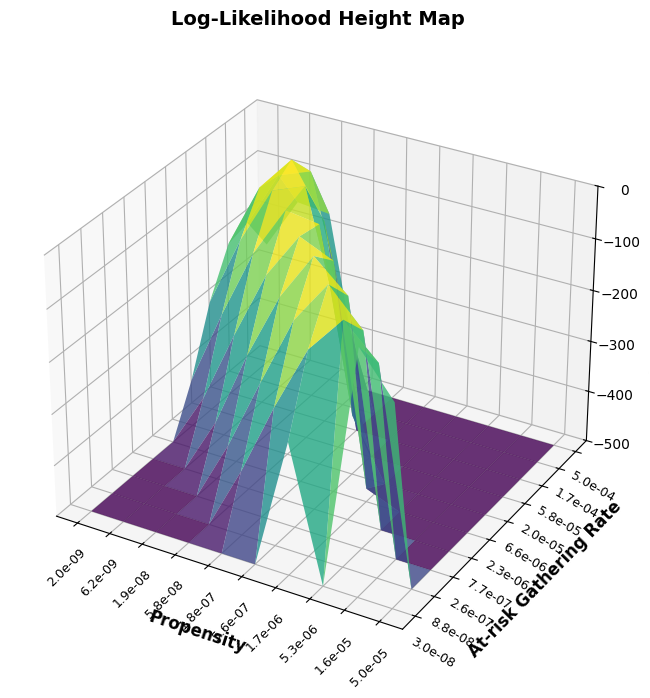

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import matplotlib as mpl

# Assuming propensity_range, atrisk_range, and mat are already defined
# If not, you would define them here

# Set figure size and resolution
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['figure.dpi'] = 100

# Create figure with a specific aspect ratio
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Create the meshgrid for plotting
X, Y = np.meshgrid(np.arange(len(propensity_range)), np.arange(len(atrisk_range)))

# Plot the surface with a professional colormap and lighting
surf = ax.plot_surface(
    X, Y, mat,
    cmap=cm.viridis,
    linewidth=0,
    antialiased=True,
    alpha=0.8,
    rstride=1,
    cstride=1,
)

# Customize the z-axis
ax.set_zlim(np.min(mat), np.max(mat))

# Add proper ticks for x and y axes using the actual range values
x_ticks = np.arange(len(propensity_range))
y_ticks = np.arange(len(atrisk_range))
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

# Set the actual values from propensity_range and atrisk_range as labels
# Comment out the next two lines if your ranges have too many values
ax.set_xticklabels([f"{p:.1e}" for p in propensity_range], fontsize=9, rotation=45)
ax.set_yticklabels([f"{a:.1e}" for a in atrisk_range], fontsize=9, rotation=-30)

# Add labels with better font styling
ax.set_xlabel('Propensity', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('At-risk Gathering Rate', fontsize=12, fontweight='bold', labelpad=10)
ax.set_zlabel('Log Likelihood', fontsize=12, fontweight='bold', labelpad=10)

# Add a title
ax.set_title('Log-Likelihood Height Map', fontsize=14, fontweight='bold', pad=20)

# Customize the grid
ax.grid(True, linestyle='--', alpha=0.6)

# Adjust the view angle for better visibility
# ax.view_init(elev=30, azim=45)

# Adjust the axes aspect ratio
# Set z-axis scale the same as x, y
# Uncomment if you want uniform scaling
# ax.set_box_aspect([1, 1, 0.7])

# Tight layout
plt.tight_layout()

# Save the figure with high resolution
# plt.savefig('log_likelihood_heightmap.png', dpi=300, bbox_inches='tight')

plt.show()

In [85]:
slice_param = 'propensity'
param_cols = ['propensity', 'walk_radius', 'arm_bias', 'arm_weight', 'atrisk_gathering_rate']
param_cols.remove(slice_param)
grouped = result_df.groupby(param_cols)

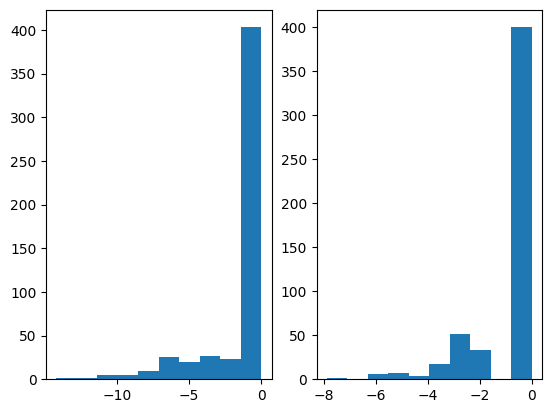

In [85]:
eval_slice_df = list(grouped)[30][1]
eval_slice_df
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2)
ind = 1
axes[0].hist(eval_slice_df.iloc[ind]['city_eval'][:, 1])
axes[1].hist(eval_slice_df.iloc[ind]['city_eval'][:, 2])
plt.show()


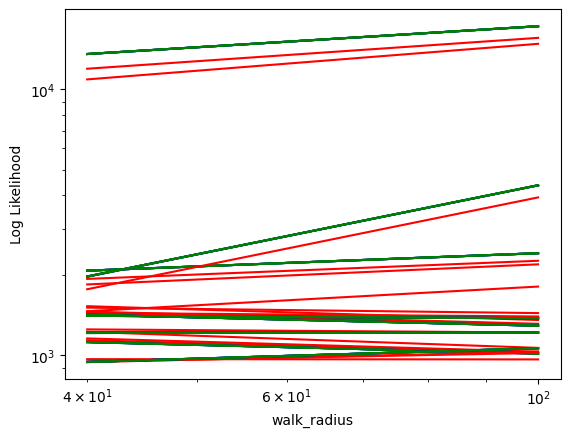

In [106]:
param_cols = ['propensity', 'walk_radius', 'arm_bias', 'arm_weight', 'atrisk_gathering_rate']
slice_param = 'walk_radius'
param_cols.remove(slice_param)
grouped = result_df.groupby(param_cols)
#Plot the log likelihood for each parameter group against the propensity
#Convert arm bias to color with a colorbar
import matplotlib.pyplot as plt
colorbar = plt.cm.ScalarMappable(cmap='viridis')
colormap = {0.01: 'red', 1: 'blue', 100: 'green'}

fig, ax = plt.subplots()
for name, group in grouped:
    # print(group)
    # print(group['arm_bias'].iloc[0])
    # if group['arm_bias'].iloc[0] in [1, 100]:
    #     continue
    ax.plot(group[slice_param], -group[0], c=colormap[group['arm_bias'].iloc[0]])
ax.set_xlabel(slice_param)
ax.set_ylabel('Log Likelihood')
ax.set_xscale('log'); ax.set_yscale('log')
# ax.legend()

/tmp/ipykernel_1199115/1978540426.py:11: MatplotlibDeprecationWarning: Passing label as a length 4 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  ax.plot(group[slice_param], -group[0], label=name)


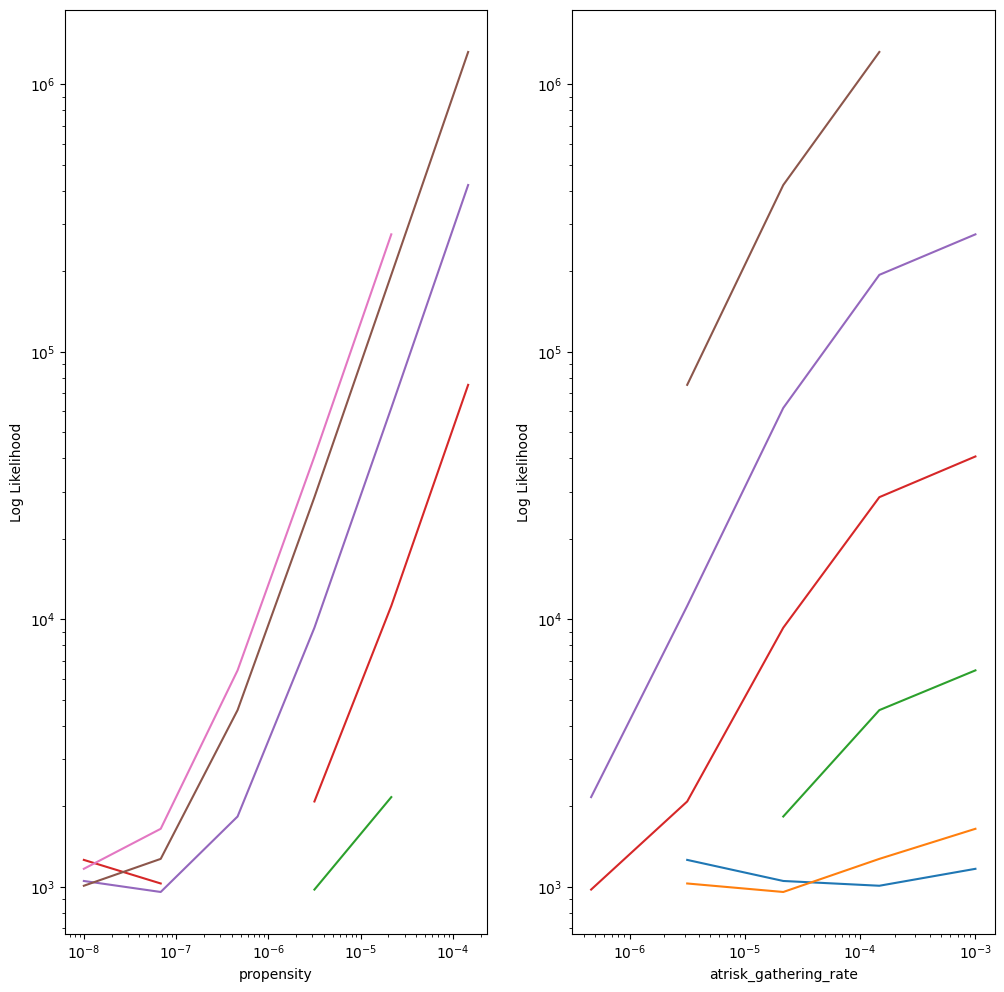

In [8]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 12))
for i, slice_param in enumerate(['propensity', 'atrisk_gathering_rate']):
    param_cols = ['propensity', 'walk_radius', 'arm_bias', 'arm_weight', 'atrisk_gathering_rate']
    param_cols.remove(slice_param)
    grouped = result_df.groupby(param_cols)
    #Plot the log likelihood for each parameter group against the propensity
    ax = axes.flatten()[i]
    for name, group in grouped:
        # print(group)
        ax.plot(group[slice_param], -group[0], label=name)
    ax.set_xlabel(slice_param)
    ax.set_ylabel('Log Likelihood')
    ax.set_xscale('log'); ax.set_yscale('log')
# plt.legend()

In [33]:
result_df.to_csv('ll_eval_df.csv', sep='\t')

,propensity,walk_radius,arm_bias,arm_weight,atrisk_gathering_rate,0,1,2,city_eval
0,1.000000e-09,100,100.00,10.0,0.01000,-1380.351081,-702.363248,-677.987833,"[[-11.386559463338571, -6.388017429059441, -4...."
1,1.000000e-09,100,100.00,10.0,0.00001,-1294.313663,-924.548481,-369.765182,"[[-11.686034708134471, -8.737510085076561, -2...."
2,1.000000e-09,100,100.00,1.0,0.01000,-1380.492305,-702.366285,-678.126020,"[[-11.37136184880398, -6.386509819584223, -4.9..."
3,1.000000e-09,100,100.00,1.0,0.00001,-1295.495239,-924.650576,-370.844663,"[[-11.675680015355386, -8.756645524987588, -2...."
4,1.000000e-09,100,100.00,0.1,0.01000,-1380.694062,-702.371623,-678.322439,"[[-11.386015411814927, -6.387891361773514, -4...."
...,...,...,...,...,...,...,...,...,...
136,1.000000e-06,40,1.00,0.1,0.01000,-13592.738040,-12915.558417,-677.179623,"[[-6.042699612758922, -1.0401257535510973, -5...."
137,1.000000e-06,40,1.00,0.1,0.00001,-1981.642327,-1620.087034,-361.555293,"[[-5.8181537599326045, -2.9939317261099427, -2..."
138,1.000000e-06,40,0.01,10.0,0.01000,-11965.191725,-11287.533260,-677.658465,"[[-6.022462020626551, -1.0406422789195824, -4...."
139,1.000000e-06,40,0.01,10.0,0.00001,-1773.899553,-1414.824390,-359.075163,"[[-5.615828918465159, -3.000477766308605, -2.6..."


In [ ]:

ll_values = np.array(list(total_ll.values()))
ll_values = ll_values[~np.isnan(ll_values) & (ll_values > -1000)]

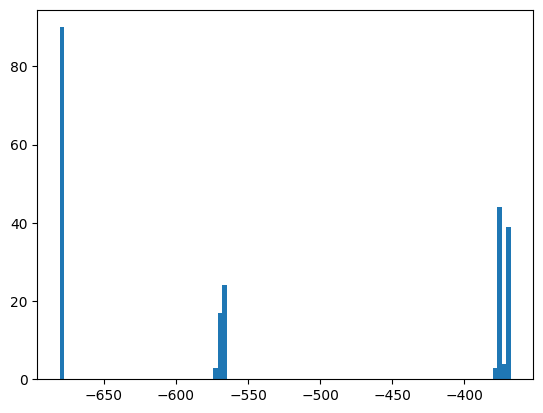

In [32]:
import matplotlib.pyplot as plt
plt.hist(ll_values, bins=100)
plt.show()